# IY025: Does the "fraction above mean" effect also appear in the IY011 (2-fold) t_ac dataset?

Companion to `IY025_tac_mechanism_investigation.ipynb`, which analysed the **IY014 (10-fold)** t_ac variation dataset and found:
- μ and CV are both held fixed for the t_ac dataset (single cluster in (μ, CV) space)
- The mRNA count distribution shape shifts from unimodal to bimodal as t_ac increases
- The fraction of timepoints above the fixed mean correlates significantly with t_ac in aggregate (r=-0.55) but is too noisy per-trajectory to directly separate same/different pairs (pair-segment test was not significant)

Here we repeat the same three analyses on the **IY011 (2-fold)** datasets — where μ=100, CV=1.0 are fixed for the t_ac variation set (different fixed values than IY014, but the same underlying mechanism) — to see whether the same trend holds at this magnitude of variation.

In [1]:
import sys
sys.path.insert(0, '../../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

# ── Plotting conventions ──────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':     'sans-serif',
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.titlesize':  14,
})
PALETTE = sns.color_palette('colorblind')

RNG = np.random.default_rng(42)

In [2]:
# ── Paths — IY011 (2-fold variation), all data lives under IY011's own root ───
IY011_ROOT = Path('../EXP-25-IY011')

DATASETS = [
    dict(
        name='baseline',
        data_dir=IY011_ROOT / 'data',
        csv='IY011_simulation_parameters_sobol.csv',
        color=PALETTE[0],
    ),
    dict(
        name='mu',
        data_dir=IY011_ROOT / 'data_mu_variation',
        csv='IY011_simulation_mu_parameters_sobol.csv',
        color=PALETTE[1],
    ),
    dict(
        name='cv',
        data_dir=IY011_ROOT / 'data_cv_variation',
        csv='IY011_simulation_cv_parameters_sobol.csv',
        color=PALETTE[2],
    ),
    dict(
        name='t_ac',
        data_dir=IY011_ROOT / 'data_t_ac_variation',
        csv='IY011_simulation_t_ac_parameters_sobol.csv',
        color=PALETTE[3],
    ),
]

# Fixed mu/CV for the IY011 t_ac dataset (different from IY014's 1000/0.5!)
MU_FIXED = 100.0
CV_FIXED = 1.0

## 1. CV vs μ scatter for all four IY011 variation datasets

In [3]:
def load_params_csv(ds):
    """Load and quality-filter the parameter CSV for a dataset."""
    df = pd.read_csv(ds['data_dir'] / ds['csv'])
    ok = (
        df['success'].astype(bool)
        & df['error_message'].isna()
        & (df['mean_rel_error_pct'] < 20)
        & (df['cv_rel_error_pct'] < 20)
        & (df['t_ac_rel_error_pct'] < 20)
    )
    return df[ok].reset_index(drop=True)

param_dfs = {ds['name']: load_params_csv(ds) for ds in DATASETS}
for name, df in param_dfs.items():
    print(f'{name:12s}: {len(df):4d} parameter sets')

baseline    : 1024 parameter sets
mu          : 1024 parameter sets
cv          : 1016 parameter sets
t_ac        : 1024 parameter sets


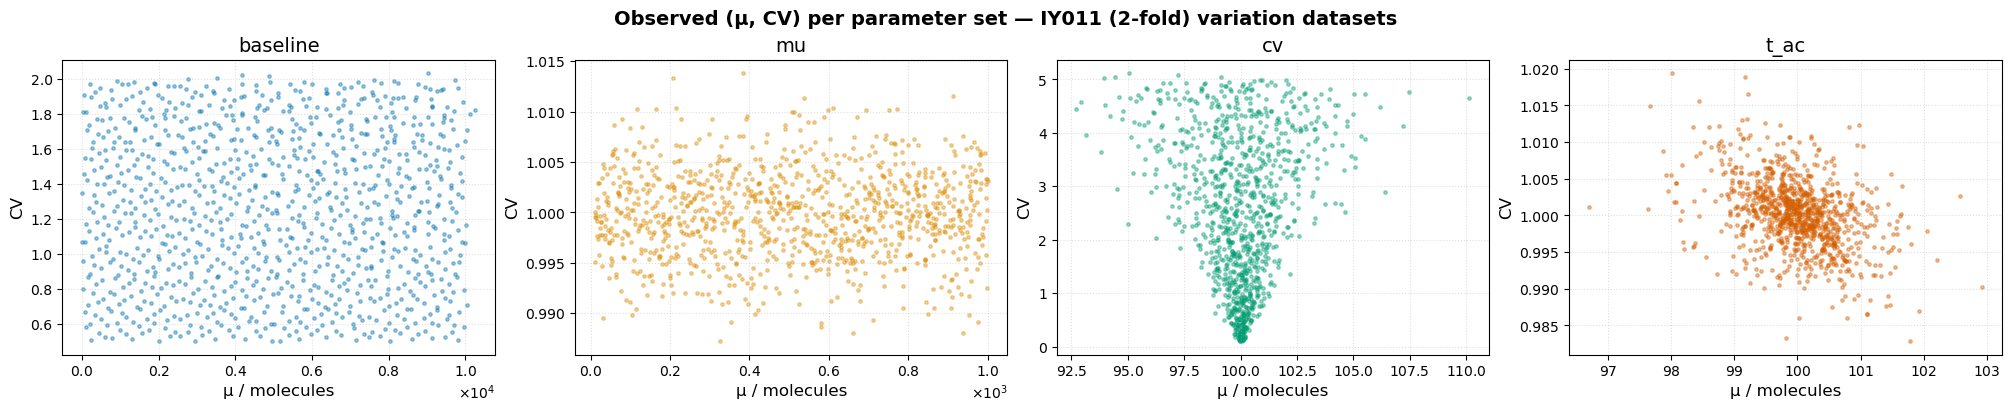

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)

for ax, ds in zip(axes, DATASETS):
    df = param_dfs[ds['name']]
    ax.scatter(
        df['mu_observed'], df['cv_observed'],
        color=ds['color'], alpha=0.4, s=6, rasterized=True,
    )
    ax.set_xlabel('μ / molecules', fontsize=12)
    ax.set_ylabel('CV', fontsize=12)
    ax.set_title(ds['name'], fontsize=14)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 3))
    ax.grid(axis='both', linestyle=':', alpha=0.4)

fig.suptitle(
    'Observed (μ, CV) per parameter set — IY011 (2-fold) variation datasets',
    fontsize=14, weight='bold',
)
plt.savefig('figures/IY025_cv_vs_mu_scatter_2fold.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. mRNA count distribution at different t_ac values (IY011)

All t_ac parameter sets here share target μ = 100 and CV = 1.0 (vs. μ=1000, CV=0.5 in IY014). t_ac ranges from ~5 to ~100 min (vs. ~2.5 to ~120 min in IY014).

In [ ]:
tac_dir = DATASETS[3]['data_dir']
df_tac = param_dfs['t_ac'].copy()
df_tac['t_ac_target'] = df_tac['t_ac_target'].round(2)

# Select 4 representative t_ac values spread across the range
t_ac_targets = [5.0, 30.0, 60.0, 95.0]
selected_rows = [
    df_tac.iloc[(df_tac['t_ac_target'] - t).abs().argsort()[:1]]
    for t in t_ac_targets
]

for row in selected_rows:
    row = row.iloc[0]
    print(f"t_ac_target={row['t_ac_target']:.1f}  →  "
          f"observed t_ac={row['t_ac_observed']:.1f}  "
          f"μ={row['mu_observed']:.0f}  CV={row['cv_observed']:.2f}  "
          f"file={row['trajectory_filename']}")

t_ac_target=5.0  →  observed t_ac=5.0  μ=100  CV=1.00  file=mRNA_trajectories_100.000_1.000_5.025.csv
t_ac_target=30.0  →  observed t_ac=29.4  μ=100  CV=1.00  file=mRNA_trajectories_100.000_1.000_29.975.csv
t_ac_target=60.0  →  observed t_ac=58.3  μ=100  CV=1.00  file=mRNA_trajectories_100.000_1.000_60.006.csv
t_ac_target=95.0  →  observed t_ac=93.5  μ=100  CV=1.00  file=mRNA_trajectories_100.000_1.000_95.019.csv


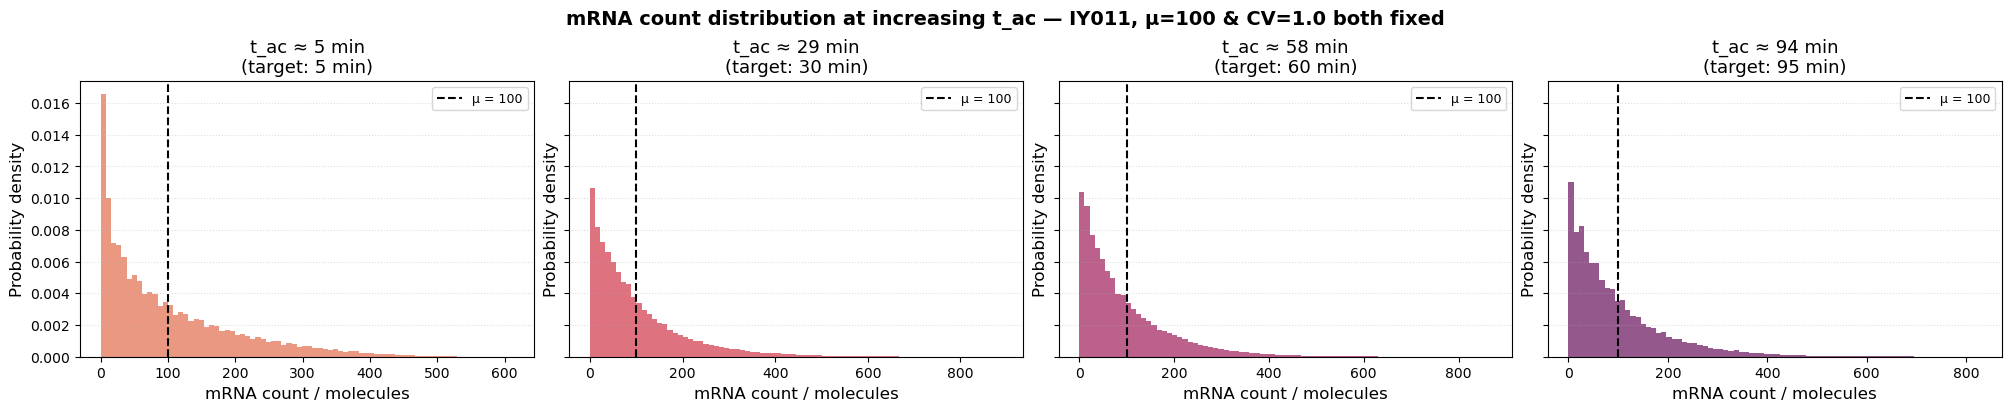

In [6]:
n_traj_per_hist = 100  # trajectories to pool per panel
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True, constrained_layout=True)
cmap_colors = sns.color_palette('flare', n_colors=4)

for ax, row_df, col in zip(axes, selected_rows, cmap_colors):
    row = row_df.iloc[0]
    npz_path = tac_dir / Path(row['trajectory_filename']).with_suffix('.npz').name
    data = np.load(npz_path, allow_pickle=True)
    trajs = data['trajectories'][:n_traj_per_hist]  # (n_traj, T)
    values = trajs.flatten()

    ax.hist(values, bins=80, density=True, color=col, alpha=0.8, edgecolor='none')
    ax.axvline(MU_FIXED, color='k', linestyle='--', linewidth=1.5, label=f'μ = {MU_FIXED:.0f}')
    ax.set_xlabel('mRNA count / molecules', fontsize=12)
    ax.set_ylabel('Probability density', fontsize=12)
    ax.set_title(
        f't_ac ≈ {row["t_ac_observed"]:.0f} min\n'
        f'(target: {row["t_ac_target"]:.0f} min)',
        fontsize=13
    )
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.4)

fig.suptitle(
    'mRNA count distribution at increasing t_ac — IY011, μ=100 & CV=1.0 both fixed',
    fontsize=14, weight='bold',
)
plt.savefig('figures/IY025_tac_count_histograms_2fold.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Fraction of timepoints above the mean vs t_ac (IY011)

In [7]:
print('Computing fraction of timepoints > μ for all IY011 t_ac parameter sets...')

records = []
npz_files = sorted(tac_dir.glob('*.npz'))

for npz_path in npz_files:
    # Filename: mRNA_trajectories_{mu}_{cv}_{t_ac}.npz
    parts = npz_path.stem.split('_')
    try:
        t_ac_val = float(parts[-1])
    except ValueError:
        continue

    data = np.load(npz_path, allow_pickle=True)
    trajs = data['trajectories']  # (1000, T)

    per_traj_frac = (trajs > MU_FIXED).mean(axis=1)  # shape (1000,)

    records.append({
        't_ac': t_ac_val,
        'frac_mean': float(per_traj_frac.mean()),
        'frac_std':  float(per_traj_frac.std()),
        'per_traj':  per_traj_frac,
    })

records.sort(key=lambda r: r['t_ac'])
print(f'Processed {len(records)} parameter sets.')

Computing fraction of timepoints > μ for all IY011 t_ac parameter sets...


Processed 1024 parameter sets.


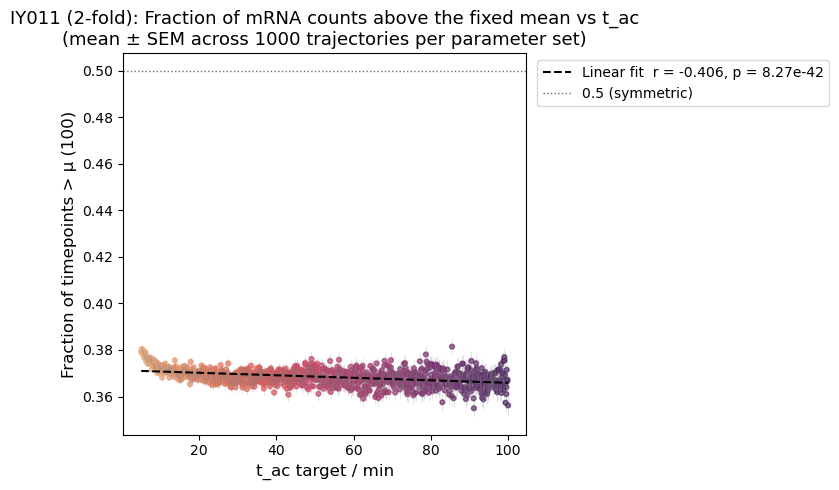

Pearson r = -0.4055, p = 8.27e-42
Fraction range: 0.3550 (high t_ac) to 0.3814 (low t_ac)


In [8]:
t_ac_arr  = np.array([r['t_ac']      for r in records])
frac_arr  = np.array([r['frac_mean'] for r in records])
frac_std  = np.array([r['frac_std']  for r in records])

r_val, p_val = stats.pearsonr(t_ac_arr, frac_arr)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    t_ac_arr, frac_arr,
    c=t_ac_arr, cmap='flare', s=12, alpha=0.7, rasterized=True,
)
ax.errorbar(
    t_ac_arr, frac_arr, yerr=frac_std / np.sqrt(1000),
    fmt='none', color='grey', alpha=0.3, linewidth=0.5,
)

m, b = np.polyfit(t_ac_arr, frac_arr, 1)
x_line = np.linspace(t_ac_arr.min(), t_ac_arr.max(), 200)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5,
        label=f'Linear fit  r = {r_val:.3f}, p = {p_val:.2e}')

ax.axhline(0.5, color='dimgrey', linestyle=':', linewidth=1, label='0.5 (symmetric)')
ax.set_xlabel('t_ac target / min', fontsize=12)
ax.set_ylabel('Fraction of timepoints > μ (100)', fontsize=12)
ax.set_title(
    'IY011 (2-fold): Fraction of mRNA counts above the fixed mean vs t_ac\n'
    '(mean ± SEM across 1000 trajectories per parameter set)',
    fontsize=13
)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('figures/IY025_frac_above_mean_vs_tac_2fold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson r = {r_val:.4f}, p = {p_val:.2e}')
print(f'Fraction range: {frac_arr.min():.4f} (high t_ac) to {frac_arr.max():.4f} (low t_ac)')

Q1: 5–29 min: median=0.3715, IQR=[0.3396, 0.4033]
Q2: 29–52 min: median=0.3670, IQR=[0.3128, 0.4222]
Q3: 52–76 min: median=0.3650, IQR=[0.2954, 0.4366]
Q4: 76–100 min: median=0.3635, IQR=[0.2819, 0.4485]


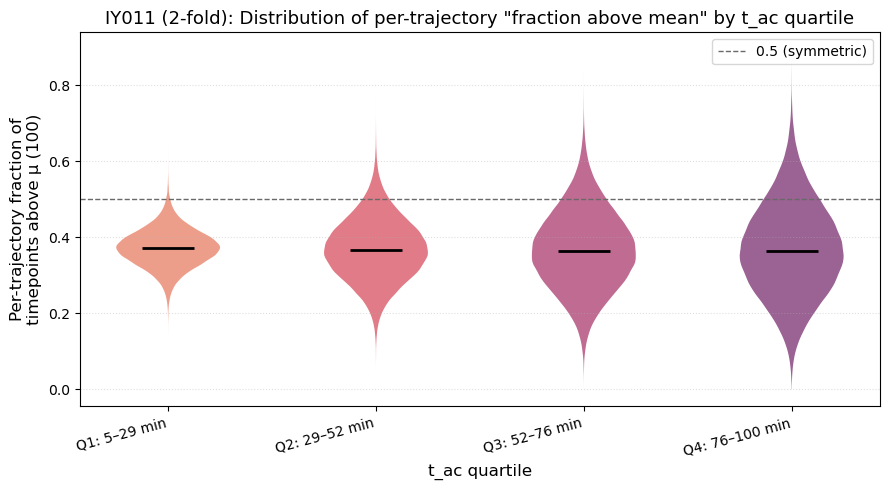

In [9]:
quartile_bounds = np.quantile(t_ac_arr, [0, 0.25, 0.5, 0.75, 1.0])
quartile_labels = [
    f'Q1: {quartile_bounds[0]:.0f}–{quartile_bounds[1]:.0f} min',
    f'Q2: {quartile_bounds[1]:.0f}–{quartile_bounds[2]:.0f} min',
    f'Q3: {quartile_bounds[2]:.0f}–{quartile_bounds[3]:.0f} min',
    f'Q4: {quartile_bounds[3]:.0f}–{quartile_bounds[4]:.0f} min',
]

quartile_fracs = []
for q in range(4):
    lo, hi = quartile_bounds[q], quartile_bounds[q + 1]
    in_q = [r for r in records if lo <= r['t_ac'] < hi + 1e-6]
    in_q = in_q[:200]
    if in_q:
        pooled = np.concatenate([r['per_traj'] for r in in_q])
        quartile_fracs.append(pooled)
    else:
        quartile_fracs.append(np.array([]))

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('flare', n_colors=4)

violin_parts = ax.violinplot(
    [qf for qf in quartile_fracs if len(qf) > 0],
    positions=np.arange(1, 5),
    showmedians=True,
    showextrema=False,
)
for body, col in zip(violin_parts['bodies'], colors):
    body.set_facecolor(col)
    body.set_alpha(0.75)
violin_parts['cmedians'].set_color('black')
violin_parts['cmedians'].set_linewidth(2)

for label, qf in zip(quartile_labels, quartile_fracs):
    print(f'{label}: median={np.median(qf):.4f}, IQR=[{np.percentile(qf,25):.4f}, {np.percentile(qf,75):.4f}]')

ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1, label='0.5 (symmetric)')
ax.set_xticks(np.arange(1, 5))
ax.set_xticklabels(quartile_labels, rotation=15, ha='right', fontsize=10)
ax.set_xlabel('t_ac quartile', fontsize=12)
ax.set_ylabel('Per-trajectory fraction of\ntimepoints above μ (100)', fontsize=12)
ax.set_title(
    'IY011 (2-fold): Distribution of per-trajectory "fraction above mean" by t_ac quartile',
    fontsize=13
)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/IY025_frac_above_mean_violin_2fold.png', dpi=150, bbox_inches='tight')
plt.show()

### 3c. Pair-segment comparison using the actual SVM input (IY011 t_ac static test set)

In [10]:
from dataloaders import load_loader_from_disk

tac_test_pt = IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_test.pt'
loader = load_loader_from_disk(tac_test_pt, batch_size=512)

all_X, all_y = [], []
for X_batch, y_batch in loader:
    all_X.append(X_batch.cpu().numpy())
    all_y.append(y_batch.cpu().numpy().ravel())

X_all = np.concatenate(all_X, axis=0).squeeze(-1)  # (N, T_total)
y_all = np.concatenate(all_y, axis=0)               # (N,)

print(f'Loaded {X_all.shape[0]} test pairs, T_total = {X_all.shape[1]}')
print(f'Label distribution: 0={int((y_all==0).sum())}, 1={int((y_all==1).sum())}')

📂 Loading static data from ../EXP-25-IY011/data_t_ac_variation/IY011_static_test.pt...
Loaded 600 test pairs, T_total = 4023
Label distribution: 0=308, 1=292


In [11]:
# T_total = 2*T + 1 (separator excluded by splitting at the midpoint)
T_total = X_all.shape[1]
T_per_seg = T_total // 2

seg1 = X_all[:, :T_per_seg]
seg2 = X_all[:, T_per_seg + 1:]

frac1 = (seg1 > 0).mean(axis=1)
frac2 = (seg2 > 0).mean(axis=1)
diff  = frac1 - frac2

print(f'seg1 shape: {seg1.shape}, seg2 shape: {seg2.shape}')

seg1 shape: (600, 2011), seg2 shape: (600, 2011)


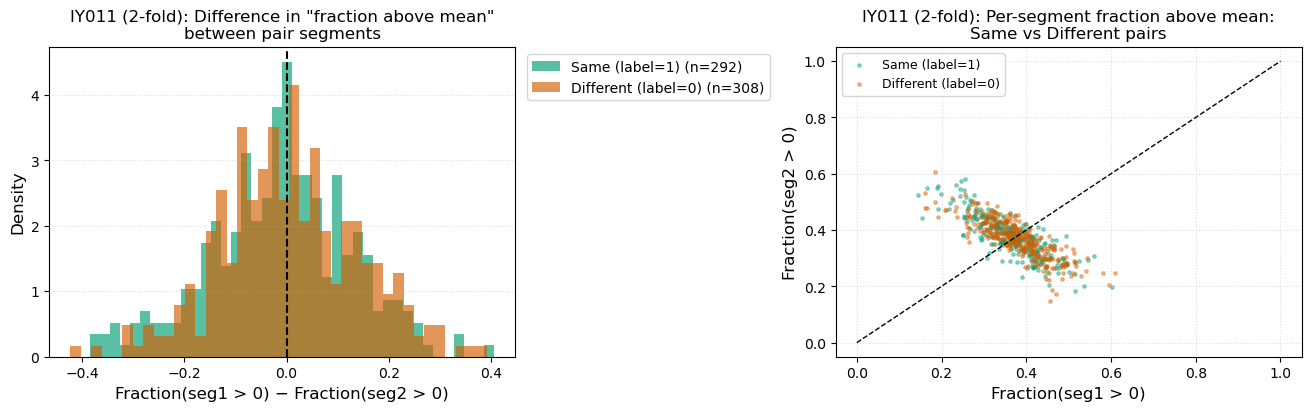

|Δ frac| — same pairs:      mean=0.1068, std=0.0879
|Δ frac| — different pairs: mean=0.1072, std=0.0831
Welch t-test: t=-0.06, p=9.54e-01


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

ax = axes[0]
for label_val, lbl_name, col in zip([1, 0], ['Same (label=1)', 'Different (label=0)'], [PALETTE[2], PALETTE[3]]):
    mask = y_all == label_val
    ax.hist(
        diff[mask], bins=40, density=True, alpha=0.65,
        color=col, label=f'{lbl_name} (n={mask.sum()})', edgecolor='none',
    )
ax.axvline(0, color='k', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fraction(seg1 > 0) − Fraction(seg2 > 0)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('IY011 (2-fold): Difference in "fraction above mean"\nbetween pair segments', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.4)

ax = axes[1]
for label_val, lbl_name, col in zip([1, 0], ['Same (label=1)', 'Different (label=0)'], [PALETTE[2], PALETTE[3]]):
    mask = y_all == label_val
    ax.scatter(frac1[mask], frac2[mask], color=col, alpha=0.4, s=6, label=lbl_name, rasterized=True)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('Fraction(seg1 > 0)', fontsize=12)
ax.set_ylabel('Fraction(seg2 > 0)', fontsize=12)
ax.set_title('IY011 (2-fold): Per-segment fraction above mean:\nSame vs Different pairs', fontsize=12)
ax.legend(fontsize=9)
ax.grid(linestyle=':', alpha=0.4)

plt.savefig('figures/IY025_pair_frac_above_mean_2fold.png', dpi=150, bbox_inches='tight')
plt.show()

same_mask = y_all == 1
diff_mask  = y_all == 0
print(f'|Δ frac| — same pairs:      mean={np.abs(diff[same_mask]).mean():.4f}, std={np.abs(diff[same_mask]).std():.4f}')
print(f'|Δ frac| — different pairs: mean={np.abs(diff[diff_mask]).mean():.4f}, std={np.abs(diff[diff_mask]).std():.4f}')
t_stat, p = stats.ttest_ind(np.abs(diff[same_mask]), np.abs(diff[diff_mask]))
print(f'Welch t-test: t={t_stat:.2f}, p={p:.2e}')

## Summary: IY011 (2-fold) vs IY014 (10-fold)

| Check | IY014 (10-fold) | IY011 (2-fold) |
|-------|------------------|-----------------|
| SVM pairwise accuracy (from IY025 main notebook) | 0.81 (highly significant) | 0.54 (not significant, p=0.064 in the permutation test) |
| (μ, CV) for t_ac dataset | fixed at (1000, 0.5) | fixed at (100, 1.0) |
| t_ac range | ~2.5–120 min | ~5–100 min |
| Aggregate fraction-above-mean vs t_ac (Pearson r) | r = −0.55, p ≈ 1.3×10⁻⁷⁹ | r = −0.41, p ≈ 8.3×10⁻⁴² |
| Fraction-above-mean range (low → high t_ac) | 0.563 → 0.424 (spread ≈ 0.14) | 0.381 → 0.355 (spread ≈ 0.026) |
| Pair-segment t-test (\|Δfrac\|, same vs different) | not significant, p = 0.74 | not significant, p = 0.95 |

**The same qualitative trend holds**: t_ac is still negatively correlated with the fraction of timepoints above the mean (r=-0.41 in IY011, even more extreme p-value due to large N, but the correlation is weaker than IY014's r=-0.55). However, the **effect size is roughly 5× smaller** in IY011 (spread of 0.026 vs 0.14) — consistent with both the smaller fold-difference used when constructing same/different pairs in IY011, and the higher baseline CV (1.0 vs 0.5) which keeps the gene "ON" a larger fraction of the time regardless of t_ac, compressing the achievable range.

At the per-trajectory level, this weaker signal is fully swallowed by noise: the pair-segment test is non-significant in **both** datasets, but the test statistic is even closer to null in IY011 (p=0.95 vs p=0.74). This is consistent with the SVM failing to discriminate t_ac pairs in IY011 (54%, chance-level) while succeeding in IY014 (81%) — the underlying shortcut feature is present in both, but only strong enough to be exploitable when the fold-difference and effect size are large enough (IY014's 10-fold regime).